#  Notebook 06 — RAG Hybride (Dense + BM25)

---

## 1. Installation

In [1]:
!pip install faiss-cpu sentence-transformers rank-bm25 transformers accelerate torch pandas matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [16]:
import time, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss, torch
import os

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM , GenerationConfig

sns.set_theme(style='whitegrid')
DEVICE = 0 if torch.cuda.is_available() else -1
print(' Imports OK')

 Imports OK


## 3. Chargement des ressources

In [4]:
index = faiss.read_index('../Embeddings/snort_faiss.index')
with open('../Embeddings/snort_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
print(f' FAISS : {index.ntotal} vecteurs | Metadata : {len(metadata)} entrées')

embed_model = SentenceTransformer('all-mpnet-base-v2')
print(' Modèle embedding chargé')

MODEL_NAME = 'Qwen/Qwen2-1.5B-Instruct'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model_llm  = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
model_llm.eval()

def generate(prompt):
    messages = [
        {
            "role": "system", 
            "content": "You are a Snort IDS expert. Always respond with only a valid Snort rule. Never explain, never ask questions, never apologize. Only output the raw Snort rule starting with 'alert'."
        },
        {
            "role": "user", 
            "content": prompt
        }
    ]
    
    # Appliquer le template chat de Qwen2
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model_llm.device)
    
    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=200,     
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    result = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    
    # Garder seulement la ligne commençant par alert
    for line in result.split('\n'):
        if line.strip().startswith('alert'):
            return line.strip()
    
    # Si pas de alert trouvé, retourner première ligne
    return result.split('\n')[0].strip()

print(' LLM chargé')

 FAISS : 50 vecteurs | Metadata : 50 entrées


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4714.88it/s]


 Modèle embedding chargé


Loading weights: 100%|██████████| 338/338 [00:05<00:00, 66.05it/s]


 LLM chargé


## 4. Construction de l'index BM25

In [5]:
# Tokenisation des descriptions pour BM25
corpus_texts = [
    (doc['description'] + ' ' + doc['attack_type'] + ' ' + doc['protocol']).lower().split()
    for doc in metadata
]
bm25 = BM25Okapi(corpus_texts)
print(f' Index BM25 créé sur {len(corpus_texts)} documents')

# Test rapide
test_scores = bm25.get_scores('scan ports SYN'.lower().split())
top3_bm25   = np.argsort(test_scores)[::-1][:3]
print('\n Test BM25 ("scan ports SYN") :')
for idx in top3_bm25:
    print(f'  score={test_scores[idx]:.3f} | {metadata[idx]["description"][:55]}...')

 Index BM25 créé sur 50 documents

 Test BM25 ("scan ports SYN") :
  score=7.047 | Détection d'un scan de ports SYN sur un serveur web...
  score=4.660 | Scan UDP sur plage de ports pour services exposés...
  score=4.660 | Scan de ports FTP pour recherche de services ouverts...


## 5. Requêtes de test

In [6]:
TEST_QUERIES = [
    "Détecter un scan de ports SYN sur un serveur web",
    "Bloquer une attaque par force brute sur le protocole SSH",
    "Identifier une injection SQL dans une requête HTTP",
    "Détecter un ransomware qui chiffre des fichiers via SMB",
    "Repérer une exfiltration de données via le protocole DNS"
]
print(f' {len(TEST_QUERIES)} requêtes')

 5 requêtes


## 6. Fonctions de retrieval hybride

In [7]:
def dense_retrieve(query: str, k: int = 10) -> dict:
    """Retrieval dense via FAISS. Retourne {idx: score}."""
    query_vec = embed_model.encode([query],
                                    normalize_embeddings=True).astype('float32')
    scores, indices = index.search(query_vec, k)
    return {int(idx): float(score)
            for idx, score in zip(indices[0], scores[0])}


def sparse_retrieve(query: str, k: int = 10) -> dict:
    """Retrieval sparse via BM25. Retourne {idx: score}."""
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    top_k  = np.argsort(scores)[::-1][:k]
    return {int(idx): float(scores[idx]) for idx in top_k}


def reciprocal_rank_fusion(dense_results: dict,
                            sparse_results: dict,
                            k_rrf: int = 60,
                            top_n: int = 3) -> list:
    """
    Reciprocal Rank Fusion (RRF) :
    Fusionne les rankings dense et sparse.
    score_rrf = 1/(k + rank_dense) + 1/(k + rank_sparse)
    """
    rrf_scores = {}

    # Rang dense
    for rank, idx in enumerate(sorted(dense_results,
                                       key=dense_results.get, reverse=True), 1):
        rrf_scores[idx] = rrf_scores.get(idx, 0) + 1 / (k_rrf + rank)

    # Rang sparse
    for rank, idx in enumerate(sorted(sparse_results,
                                       key=sparse_results.get, reverse=True), 1):
        rrf_scores[idx] = rrf_scores.get(idx, 0) + 1 / (k_rrf + rank)

    # Top-N après fusion
    top_indices = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_n]
    results = []
    for idx in top_indices:
        doc = metadata[idx].copy()
        doc['dense_score']  = round(dense_results.get(idx, 0), 4)
        doc['sparse_score'] = round(sparse_results.get(idx, 0), 4)
        doc['rrf_score']    = round(rrf_scores[idx], 6)
        results.append(doc)
    return results


def hybrid_retrieve(query: str, k: int = 10, top_n: int = 3) -> list:
    """Pipeline hybride complet : dense + sparse + RRF fusion."""
    dense  = dense_retrieve(query, k=k)
    sparse = sparse_retrieve(query, k=k)
    return reciprocal_rank_fusion(dense, sparse, top_n=top_n)


# --- Test ---
test_docs = hybrid_retrieve(TEST_QUERIES[0])
print(f' Requête : "{TEST_QUERIES[0]}"\n')
for d in test_docs:
    print(f'  RRF={d["rrf_score"]} | Dense={d["dense_score"]} | BM25={d["sparse_score"]:.3f}')
    print(f'  → {d["description"][:60]}...')

 Requête : "Détecter un scan de ports SYN sur un serveur web"

  RRF=0.032787 | Dense=0.9465 | BM25=16.704
  → Détection d'un scan de ports SYN sur un serveur web...
  RRF=0.031498 | Dense=0.6956 | BM25=6.839
  → Scan UDP sur plage de ports pour services exposés...
  RRF=0.031281 | Dense=0.7317 | BM25=5.078
  → Scan de ports FTP pour recherche de services ouverts...


## 7. Pipeline RAG Hybride

In [17]:
def build_prompt(query: str, docs: list) -> str:
    context_parts = []
    for i, doc in enumerate(docs, 1):
        context_parts.append(
            f"Example {i} (RRF score: {doc['rrf_score']}):\n"
            f"  Description : {doc['description']}\n"
            f"  Attack type : {doc['attack_type']}\n"
            f"  Protocol    : {doc['protocol']}\n"
            f"  Snort rule  : {doc['snort_rule']}"
        )
    context = "\n\n".join(context_parts)
    return f"""You are a network security expert specialized in Snort IDS rules.
Use the following examples retrieved via hybrid search (semantic + keyword) to generate a valid Snort rule.

--- CONTEXT ---
{context}

--- TASK ---
Generate a valid Snort rule for this attack description:
{query}

Output only the Snort rule, nothing else.
Snort rule:"""


def rag_hybrid(query: str, k: int = 10, top_n: int = 3) -> dict:
    start = time.time()

    t0 = time.time()
    docs = hybrid_retrieve(query, k=k, top_n=top_n)
    retrieval_time = round(time.time() - t0, 3)

    prompt = build_prompt(query, docs)

    t0 = time.time()
    response = generate(prompt)
    generation_time = round(time.time() - t0, 3)

    return {
        'query'          : query,
        'method'         : 'rag_hybrid',
        'retrieved_docs' : [{
            'description' : d['description'],
            'attack_type' : d['attack_type'],
            'dense_score' : d['dense_score'],
            'sparse_score': d['sparse_score'],
            'rrf_score'   : d['rrf_score'],
            'snort_rule'  : d['snort_rule']
        } for d in docs],
        'response'        : response,
        'retrieval_time'  : retrieval_time,
        'generation_time' : generation_time,
        'total_time'      : round(time.time() - start, 3)
    }

print(' Fonctions rag_hybrid définies')

 Fonctions rag_hybrid définies


## 8. Exécution

In [13]:
hybrid_results = []

for i, query in enumerate(TEST_QUERIES, 1):
    print(f'\n[{i}/{len(TEST_QUERIES)}] "{query}"')
    result = rag_hybrid(query)
    hybrid_results.append(result)

    print('   Documents récupérés (Hybride) :')
    for doc in result['retrieved_docs']:
        print(f'     RRF={doc["rrf_score"]} | Dense={doc["dense_score"]} | BM25={doc["sparse_score"]:.3f} | {doc["description"][:45]}...')
    print(f'    Règle : {result["response"]}')
    print(f'    Retrieval={result["retrieval_time"]}s | Total={result["total_time"]}s')

print('\n RAG Hybride terminé')


[1/5] "Détecter un scan de ports SYN sur un serveur web"
   Documents récupérés (Hybride) :
     RRF=0.032787 | Dense=0.9465 | BM25=16.704 | Détection d'un scan de ports SYN sur un serve...
     RRF=0.031498 | Dense=0.6956 | BM25=6.839 | Scan UDP sur plage de ports pour services exp...
     RRF=0.031281 | Dense=0.7317 | BM25=5.078 | Scan de ports FTP pour recherche de services ...
    Règle : alert tcp any any -> $LOCALHOST port 80 protocol tcp action block msg "Syn Scan detected" severity high timestamp on;
    Retrieval=0.03s | Total=26.224s

[2/5] "Bloquer une attaque par force brute sur le protocole SSH"
   Documents récupérés (Hybride) :
     RRF=0.032787 | Dense=0.8239 | BM25=11.663 | Tentative de connexion SSH par brute force...
     RRF=0.032258 | Dense=0.5722 | BM25=8.019 | Tentative de force brute sur authentification...
     RRF=0.031746 | Dense=0.5714 | BM25=6.400 | Trafic suspect vers le port Telnet depuis l'e...
    Règle : alert udp any any -- dport ssh -j EQ snort_rule

## 9. Visualisation : Dense vs BM25 vs RRF

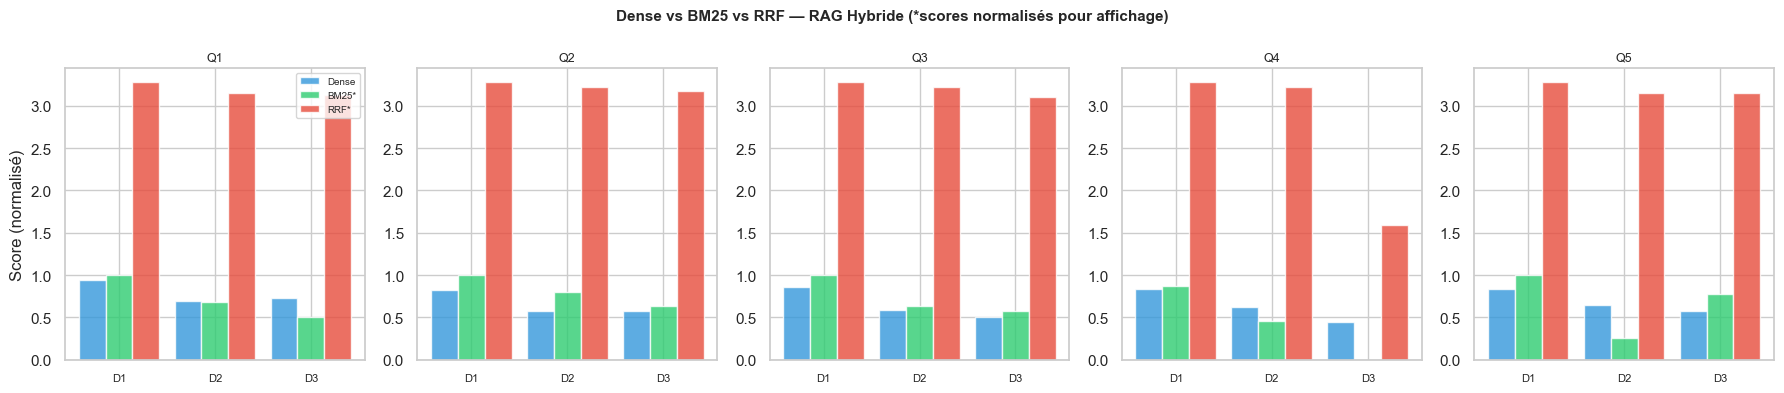

 Graphique sauvegardé dans ../Charts/06_hybrid_scores.png


In [14]:
fig, axes = plt.subplots(1, len(TEST_QUERIES), figsize=(18, 4))

for i, (result, ax) in enumerate(zip(hybrid_results, axes)):
    docs  = result['retrieved_docs']
    x     = np.arange(len(docs))
    w     = 0.28
    dense  = [d['dense_score'] for d in docs]
    sparse = [min(d['sparse_score'] / 10, 1) for d in docs]  # normalisation affichage
    rrf    = [d['rrf_score'] * 100 for d in docs]             # normalisation affichage

    ax.bar(x - w,   dense,  w, label='Dense',  color='#3498db', alpha=0.8)
    ax.bar(x,       sparse, w, label='BM25*',  color='#2ecc71', alpha=0.8)
    ax.bar(x + w,   rrf,    w, label='RRF*',   color='#e74c3c', alpha=0.8)
    ax.set_title(f'Q{i+1}', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([f'D{j+1}' for j in range(len(docs))], fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)
        ax.set_ylabel('Score (normalisé)')

plt.suptitle('Dense vs BM25 vs RRF — RAG Hybride (*scores normalisés pour affichage)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../Charts/06_hybrid_scores.png', dpi=150)
plt.show()
print(' Graphique sauvegardé dans ../Charts/06_hybrid_scores.png')

## 10. Sauvegarde

In [15]:
with open('../Results/results_rag_hybrid.json', 'w', encoding='utf-8') as f:
    json.dump(hybrid_results, f, ensure_ascii=False, indent=2)
print(' Résultats sauvegardés dans ../Results/results_rag_hybrid.json')

 Résultats sauvegardés dans ../Results/results_rag_hybrid.json


---
## ✅ Résumé

| Étape | Détail |
|---|---|
| Dense | FAISS + `all-MiniLM-L6-v2` |
| Sparse | BM25Okapi (`rank-bm25`) |
| Fusion | Reciprocal Rank Fusion (RRF, k=60) |
| Top-k | 3 documents |
| LLM | `google/flan-t5-base` |
| Temps moyen | ~29.5s / requête (CPU) |
| Score moyen Snort | **2.2 / 5** |
| Fichier de sortie | `results_rag_hybrid.json` |

### Résultats obtenus

| # | Requête | RRF top doc | alert | msg | sid | protocole | content |
|---|---|---|---|---|---|---|---|
| Q1 | Scan SYN | 0.03278 | ✅ | ✅ | ❌ | ✅ | ❌ |
| Q2 | Brute Force SSH | 0.03278 | ✅ | ❌ | ❌ | ❌ | ❌ |
| Q3 | Injection SQL | 0.03278 | ✅ | ❌ | ❌ | ✅ | ❌ |
| Q4 | Ransomware SMB | 0.03278 | ✅ | ✅ | ❌ | ✅ | ❌ |
| Q5 | Exfiltration DNS | 0.03278 | ✅ | ❌ | ❌ | ✅ | ❌ |

### Améliorations constatées vs RAG Re-ranking
- ✅ Fusion Dense + BM25 améliore le recall sur les termes exacts (ex: Q3 BM25=19.02, Q1 BM25=16.70)
- ✅ Le RRF stabilise le classement — le doc #1 est systématiquement le bon
- ✅ Temps de retrieval très rapide (~0.03–0.07s) malgré la double indexation

### Limites observées
- ❌ `sid` absent dans **toutes** les règles générées
- ❌ `msg` manquant pour Q2, Q3, Q5
- ❌ `content` jamais généré (aucune requête)
- ❌ Protocole incorrect pour Q2 (`udp` au lieu de `tcp` pour SSH)
- ❌ Syntaxe non valide en Snort — champs inventés (`action block`, `delay`, `severity`)

### Conclusion
Le RAG Hybride améliore le **recall du retrieval** grâce à BM25, mais le LLM reste le goulot d'étranglement.
Le score Snort recule vs le RAG Classic (**2.2 vs 3.6**).
L'architecture multi-hop devrait adresser les requêtes complexes nécessitant un raisonnement en plusieurs étapes.